# Phần 1

# Đọc dữ liệu đầu vào

In [4]:
import pandas as pd
import seaborn as sb

Docc = sb.load_dataset("iris")


## Hiển thị 5 dòng đầu tiên

In [5]:
print(Docc.head(5))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


## In số cột, số dòng

In [6]:
print(Docc.shape)

(150, 5)


Có 15 dòng, 6 cột

# In kiểu dữ liệu của từng cột

In [7]:
print(Docc.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


# Tính mean, median, mode, var, std, min, max, Q1, Q3 và IQR với mỗi cột

In [8]:
numeric_data = Docc.select_dtypes(include="float64")

mean = numeric_data.mean()
median = numeric_data.median()
mode = numeric_data.mode().iloc[0]
var = numeric_data.var()
std = numeric_data.std()
minn = numeric_data.min()
maxx = numeric_data.max()

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)

IQR = Q3 - Q1

print("Mean:")
print(mean)

print("\nMedian:")
print(median)

print("\nMode:")
print(mode)

print("\nVariance:")
print(var)

print("\nStandard Deviation:")
print(std)

print("\nMin:")
print(minn)

print("\nMax:")
print(maxx)

print("\nQ1:")
print(Q1)

print("\nQ3:")
print(Q3)

print("\nIQR:")
print(IQR)

Mean:
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

Median:
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

Mode:
sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64

Variance:
sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

Standard Deviation:
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

Min:
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64

Max:
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64

Q1:
sepal_length    5.1
sepal_width     2.8
petal_length    1.6
petal_width     0.3
Name: 0.25, dtype: float64

Q3:
sepal_length    6.4
sepal_width     3.3
petal_length    5.1
petal_width     1.8

# Phân loại

Tính mean, std

In [9]:
print("Mean:")
print(Docc.groupby("species").mean(numeric_only=True))

print("\nStd:")
print(Docc.groupby("species").std(numeric_only=True))

Mean:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026

Std:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


## Nhận xét:
Trong ba loài hoa, setosa có kích thước nhỏ nhất và độ biến thiên thấp, cho thấy đặc trưng khá ổn định và dễ nhận diện. versicolor nằm ở mức trung gian nhưng có sự chồng lấn với virginica ở một số đặc trưng, đặc biệt là kích thước cánh hoa. virginica có giá trị trung bình cao nhất ở hầu hết các thuộc tính (đặc biệt là petal_length và petal_width), đồng thời cũng có độ lệch chuẩn lớn hơn, thể hiện mức độ phân tán dữ liệu cao hơn.

Xét về khả năng phân biệt, petal_length và petal_width là hai đặc trưng quan trọng nhất, giúp tách setosa khỏi hai loài còn lại rất rõ ràng, trong khi versicolor và virginica có mức độ tương đồng nhất định.

# Phần 2

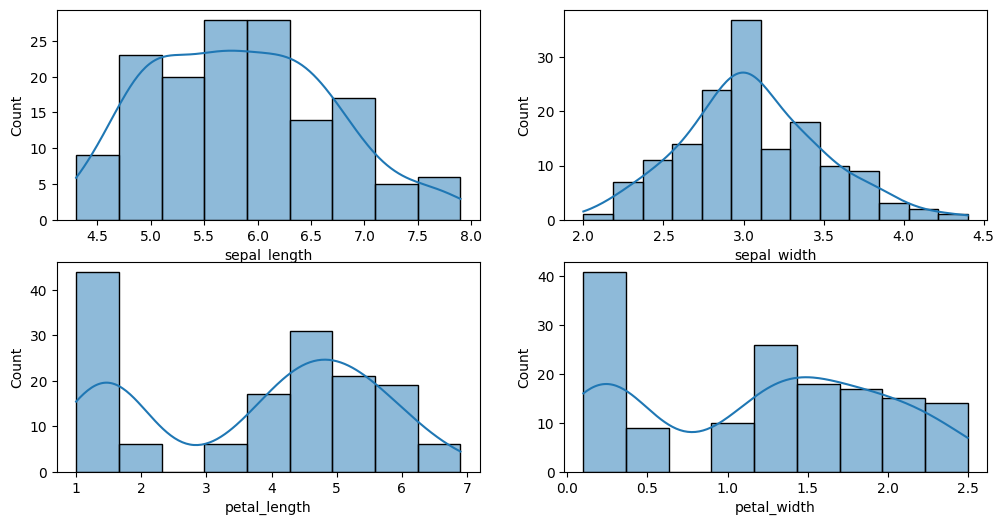

In [10]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
sb.histplot(Docc["sepal_length"],ax = axes[0][0], kde=True)
sb.histplot(Docc["sepal_width"],ax = axes[0][1], kde=True)
sb.histplot(Docc["petal_length"],ax = axes[1][0], kde=True)
sb.histplot(Docc["petal_width"],ax = axes[1][1], kde=True)

plt.show()


Dựa trên các biểu đồ histogram, có thể thấy hai biến sepal_length và sepal_width có dạng phân phối tương đối gần với phân phối chuẩn, với hình dạng khá cân đối và chỉ hơi lệch nhẹ (sepal_length hơi lệch phải, sepal_width hơi lệch trái). Ngược lại, hai biến petal_length và petal_width không tuân theo phân phối chuẩn mà thể hiện rõ dạng phân phối đa đỉnh, cho thấy sự tồn tại của nhiều nhóm dữ liệu bên trong (tương ứng với các loài hoa khác nhau). Đặc biệt, hai biến này có sự tách biệt rõ ràng giữa các cụm giá trị, phản ánh khả năng phân loại tốt hơn so với hai biến còn lại. Tổng thể, dữ liệu không hoàn toàn chuẩn hóa theo phân phối Gaussian, trong đó các đặc trưng liên quan đến cánh hoa mang tính phân cụm mạnh và có giá trị cao trong việc phân biệt các lớp.

# Vẽ boxplot

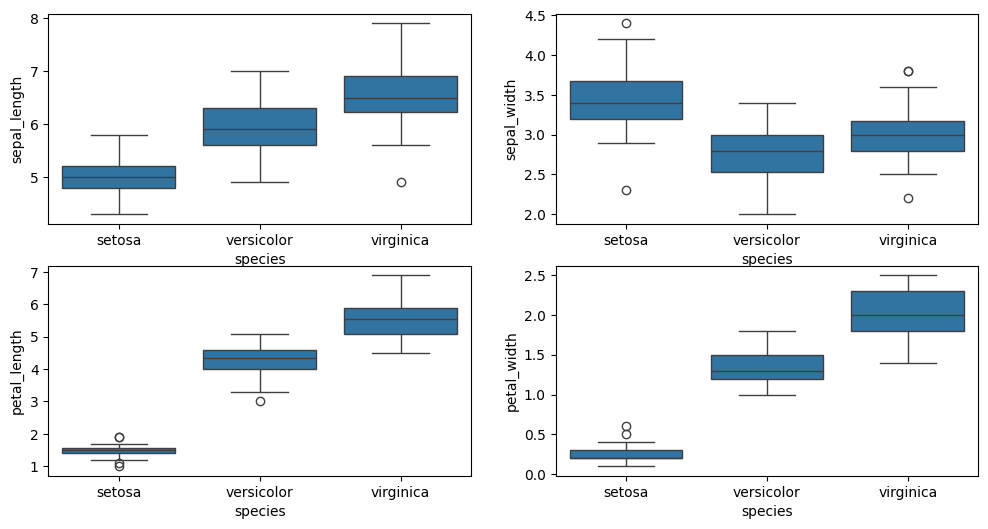

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
sb.boxplot(x=Docc["species"],y=Docc["sepal_length"],ax = axes[0][0])
sb.boxplot(x=Docc["species"],y=Docc["sepal_width"],ax = axes[0][1])
sb.boxplot(x=Docc["species"],y=Docc["petal_length"],ax = axes[1][0])
sb.boxplot(x=Docc["species"],y=Docc["petal_width"],ax = axes[1][1])

plt.show()

# Mô phỏng

<Axes: xlabel='sepal_length', ylabel='Density'>

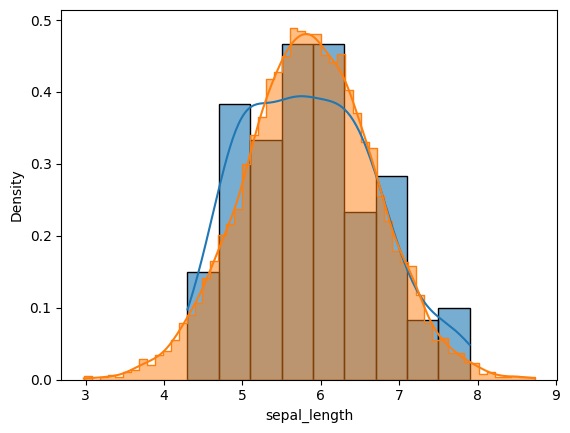

In [26]:
sepal_length_mean = Docc["sepal_length"].mean()
sepal_length_std = Docc["sepal_length"].std()

sb.histplot(x=Docc["sepal_length"], kde=True, stat="density", alpha=0.6)
sb.histplot(x=np.random.normal(sepal_length_mean, sepal_length_std, 10000), kde=True, stat="density", element="step", fill=True)

# Nhận xét
Về hình dáng đồ thị: Biểu đồ histogram của dữ liệu thực tế (sepal_length) có dạng hình chuông khá đối xứng, đỉnh tập trung cao nhất ở khoảng giá trị mean ($\approx 5.84$ cm) và thấp dần một cách đồng đều về hai phía đáy.

Kết luận: Biến sepal_length của dataset Iris có mức độ khớp rất tốt và hoàn toàn tuân theo quy luật của phân phối chuẩn (Normal Distribution) trong thực tế. Những điểm mấp mô nhỏ trên các cột histogram hoàn toàn là do kích thước mẫu thực tế khá giới hạn (150 dòng) chứ không làm ảnh hưởng đến tính chất chuẩn của tổng thể. 